In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [2]:
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
x

array([[ 0.136696  , -2.5754232 ],
       [ 5.0944021 , -4.58982038],
       [-5.35785015, -7.35060404],
       ...,
       [-3.86587349, -8.83488433],
       [-1.24238726, -3.70769069],
       [-0.65494637, -2.83086866]], shape=(1000, 2))

In [4]:
y

array([2, 1, 0, 2, 1, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 1,
       2, 2, 1, 1, 2, 2, 0, 2, 2, 1, 1, 2, 2, 2, 1, 0, 0, 2, 0, 0, 2, 0,
       2, 2, 2, 2, 2, 0, 1, 0, 2, 0, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0, 2, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 0, 2, 0, 1, 0, 0, 2, 1, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 1, 0, 1, 1, 0, 0, 2, 1, 0, 2, 2, 1, 2, 2, 1,
       1, 1, 1, 0, 2, 0, 2, 2, 0, 1, 0, 2, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2,
       0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1,
       1, 1, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 0,
       1, 1, 0, 1, 0, 2, 0, 2, 1, 0, 2, 0, 1, 2, 0, 0, 2, 2, 1, 0, 1, 1,
       0, 0, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 2, 2, 0, 0, 1, 1, 1, 2, 2, 0, 2, 0, 0, 2, 1, 2, 1, 1, 2, 0,
       1, 1, 2, 2, 1, 2, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 1, 2, 0, 2, 2, 2,
       2, 1, 0, 2, 1, 0, 1, 1, 2, 1, 1, 1, 2, 1, 0,

In [5]:
from sklearn.datasets import make_blobs


In [6]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

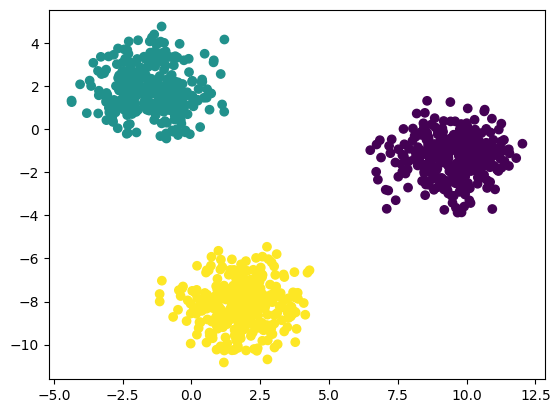

In [7]:
plt.scatter(x[:,0],x[:,1],c=y)

In [8]:
### standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [10]:
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [11]:
x_test_scaled

array([[ 1.77832371,  0.30493131],
       [-0.86678825,  1.04417552],
       [-1.615817  ,  1.10861458],
       [-1.24934209,  0.77315174],
       [-1.31513077,  0.87322929],
       [-0.55326622, -1.41524119],
       [-1.47010549,  0.9893364 ],
       [-0.93732693,  0.87831495],
       [-1.40982483,  1.01402719],
       [ 1.20058772,  0.40694591],
       [-0.61484988, -0.91762149],
       [-0.55348284, -1.78159398],
       [-0.46531853, -1.12544224],
       [-0.10270006, -1.75876813],
       [ 1.40268833, -0.03073424],
       [-0.03680364, -1.32229224],
       [-0.84701855, -1.13431999],
       [-1.24286101,  1.36159741],
       [-0.90281151,  1.21040413],
       [ 1.13767003, -0.04039852],
       [-1.23711103,  1.57572986],
       [ 0.76284111, -0.0400278 ],
       [ 1.60873746,  0.21972756],
       [ 1.42417208,  0.23298806],
       [ 1.24918096,  0.33416027],
       [ 1.26975398,  0.41690578],
       [ 1.35288547, -0.28681489],
       [-1.06158105,  1.16925376],
       [-0.30850106,

In [12]:
from sklearn.cluster import KMeans

In [13]:
##elbow method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss


[1340.000000000001,
 721.0337384190705,
 68.54113608647089,
 60.384129454896254,
 54.64286730526339,
 46.03491576534659,
 40.0977504120081,
 34.17996932258093,
 31.330166289913635,
 28.271144897122124]

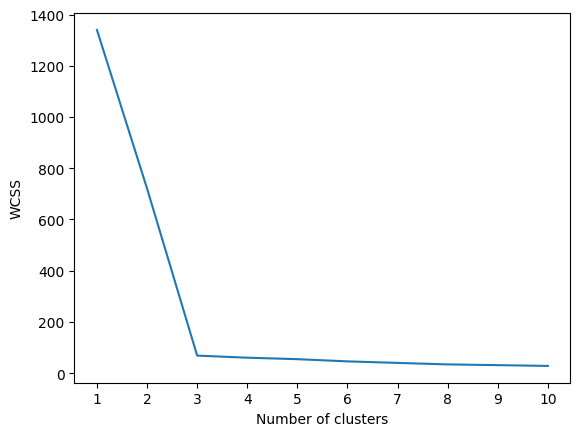

In [15]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(x_train_scaled)

array([0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 2, 0,
       2, 0, 0, 1, 1, 0, 1, 1, 0, 2, 0, 2, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1,
       0, 0, 1, 0, 1, 0, 2, 1, 1, 2, 1, 2, 1, 0, 2, 1, 0, 1, 1, 2, 1, 1,
       1, 0, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 1, 2, 1, 0,
       0, 2, 2, 2, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 1, 0, 2, 2, 0, 0,
       2, 0, 0, 1, 1, 1, 0, 1, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 2, 1, 1, 1, 0, 2, 0, 1, 2, 1, 1, 0, 0, 2, 2,
       2, 2, 1, 2, 0, 2, 1, 2, 1, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0, 0, 1, 2,
       1, 2, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 2, 1, 1, 0, 2, 0, 2, 2, 1, 2,
       0, 0, 1, 2, 0, 2, 0, 2, 2, 0, 1, 2, 2, 0, 2, 1, 1, 1, 2, 1, 1, 2,
       2, 0, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 0, 2, 0, 1, 1, 0, 2, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 0,

In [18]:
y_pred=kmeans.predict(x_test_scaled)

In [19]:
y_pred

array([1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 2, 0, 1, 2, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 0, 2, 1,
       2, 2, 1, 0, 2, 1, 0, 2, 2, 1, 2, 0, 0, 1, 2, 1, 0, 0, 1, 0, 1, 2,
       2, 2, 2, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0,
       2, 2, 1, 1, 1, 2, 2, 2, 1, 0, 2, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 2,
       2, 1, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 1, 0, 1, 0, 2, 2, 0, 0,
       2, 0, 2, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0, 2, 0, 0, 2, 1, 1, 2, 1, 1,
       2, 1, 1, 2, 2, 2, 2, 0, 0, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 0, 1,
       1, 0, 1, 0, 1, 1, 2, 0, 0, 0, 1, 2, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0,
       2, 2, 0, 1, 2, 0, 2, 0, 2, 2, 0, 0, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0,
       1, 1, 0, 2, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 1, 0, 2, 0, 1,
       0, 0, 0, 2, 1, 0, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2, 0, 1,
       1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 1, 2, 1, 0, 2, 2, 0, 1, 1, 2, 2, 0,
       2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,

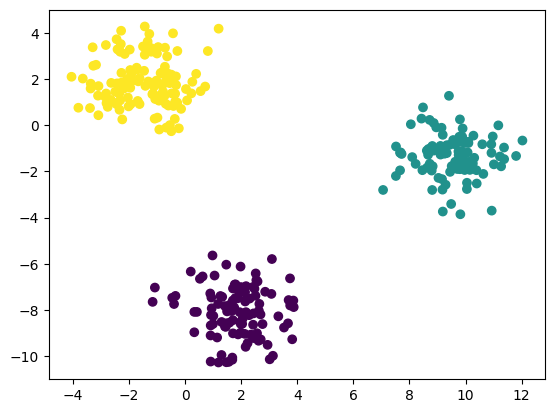

In [21]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [22]:
## validating the k value 
## kneelocator
%pip install kneed

In [23]:
from kneed import KneeLocator


In [25]:
k1=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [27]:
k1.elbow

np.int64(3)

In [28]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [32]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

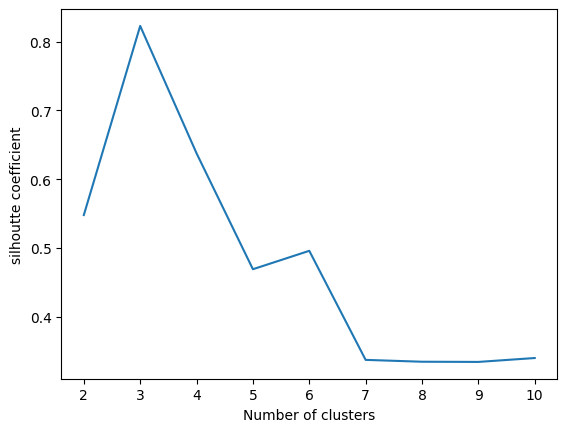

In [33]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhoutte coefficient")
plt.show()